## Gaussian smoothing (Open in Colab):


We multiply the image in Fourier space times a Nd-Gaussian.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Gausssian mask:

$$f(x,y) = A \exp\left(-\left(\frac{(x - x_0)^2}{2\sigma_X^2} + \frac{(y - y_0)^2}{2\sigma_Y^2} \right)\right)$$

In [2]:
def mask_gaussian(x, y, sigma_x, sigma_y):
    """
    Function to get the 2D gaussian
    """

    return (1/(2*np.pi*sigma_x*sigma_y) *\
            np.exp(-(x**2/(2*sigma_x**2) \
                   + y**2/(2*sigma_y**2))))

### Grid:

In [3]:
# We select the sigmas
sigma_x = 0.1
sigma_y = 0.1

# We generate the vectors
x = np.linspace(-10, 10, 1600)  # Define x coordinates
y = np.linspace(-10, 10, 1600)  # Define y coordinates

# We create the meshgrid
X, Y = np.meshgrid(x, y)

# For the surface
Z = mask_gaussian(X, Y, sigma_x, sigma_y)



<ipython-input-4-317fae2e327f>:5: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(Z), shading='auto', cmap ="viridis")


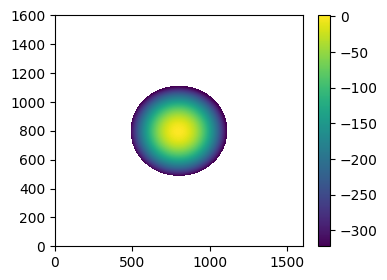

In [4]:
#2D projection of the surface

plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(Z), shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()

<ipython-input-5-33cb7eff4b5e>:5: RuntimeWarning: divide by zero encountered in log10
  surf = ax.plot_surface(X, Y, np.log10(Z), cmap ="viridis", clim= (-20, 0))


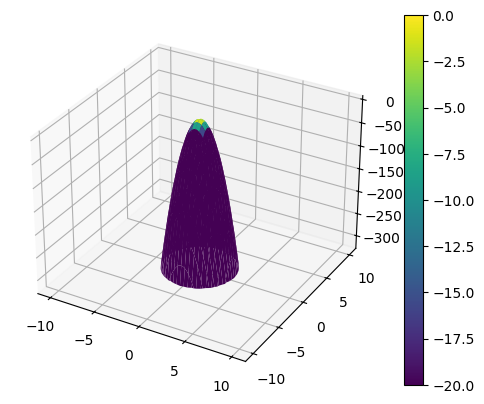

In [5]:
#3D surface

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, np.log10(Z), cmap ="viridis", clim= (-20, 0))
fig.colorbar(surf)

plt.show()

### Rubik's cube

In [6]:
from google.colab import drive
import matplotlib.image as mpimg

In [7]:
# Read image:

drive.mount('/content/drive')

img = mpimg.imread("/content/drive/MyDrive/Colab Notebooks/data/Rubiks_cube.jpg")
print(img.shape)

# 2D image:

image_3 = img[:,:,0]
print(image_3.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1600, 1600, 3)
(1600, 1600)


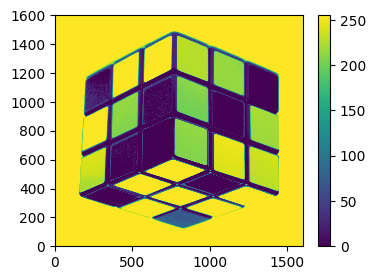

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(image_3, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()
plt.savefig("original.jpg")

### Fourier analysis:

In [9]:
#Signal
fourier_3 = np.fft.fft2(image_3)

shifted_fourier_3 = np.fft.fftshift(fourier_3)

#FT of the gaussian, which is also a gaussian in Fourier space
mask_3 = np.fft.fft2(Z)

shifted_mask_3 = np.fft.fftshift(mask_3)

### Fourier transform of the image:

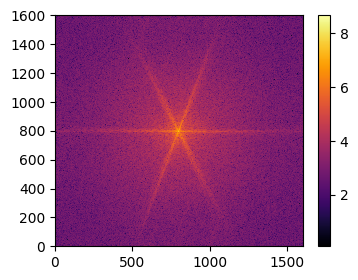

In [10]:
# Plot the signal in Fourier space
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(np.abs(shifted_fourier_3)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Fourier transform of the Gaussian mask:
It's also a gaussian in Fourier space.

<ipython-input-11-2646ea61ca43>:5: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(np.abs(shifted_mask_3)), shading='auto', cmap ="inferno")


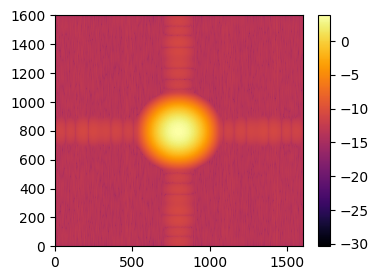

In [11]:
#Plotting

plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(np.abs(shifted_mask_3)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

### Multiply the mask by the Fourier image:

In [12]:
masked_3 = shifted_fourier_3*shifted_mask_3

<ipython-input-13-732229c4e0a5>:3: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(np.log10(np.abs(masked_3)), shading='auto', cmap ="inferno")


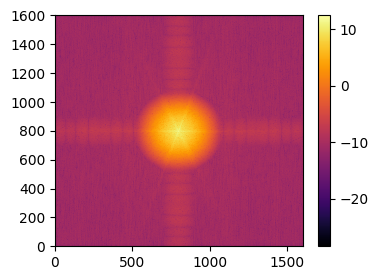

In [13]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(np.log10(np.abs(masked_3)), shading='auto', cmap ="inferno")

plt.colorbar(Z1)

plt.show()

We see some of the traces of the cube in Fourier space.

### Inverse Fourier transform:


In [14]:
#First, we unshift the mask
inv_filter_3 = np.fft.ifftshift(masked_3)

#Then, we carry out the IFFT
inv_filter_3 = np.fft.ifft2(inv_filter_3)

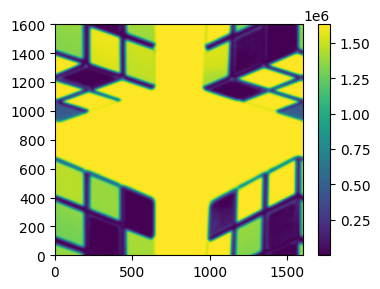

In [15]:
#Plot masked image
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(inv_filter_3.real, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()

### Rolling the image:

In [16]:
# Let's check how np.roll works

a = np.array([0,1,2,3,4,5,6,7,8,9])

print(a, a.shape)

b = np.roll(a, shift= 2)

print(b)

c= np.roll(a, shift=a.shape[0]//2)

print(c)

[0 1 2 3 4 5 6 7 8 9] (10,)
[8 9 0 1 2 3 4 5 6 7]
[5 6 7 8 9 0 1 2 3 4]


In [17]:
#Roll along the x axis, from the middle
inv_x = np.roll(inv_filter_3.real, inv_filter_3.shape[1]//2, axis = 1)

#Roll along the y axis, from the middle
inv_xy = np.roll(inv_x, inv_filter_3.shape[0]//2, axis = 0)

### Rolled image:

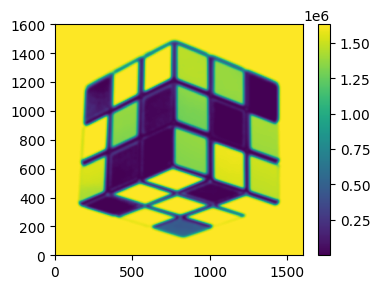

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(inv_xy, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()
plt.savefig("sigma_0.1.png")

We can use different sigma values of the Gaussian to sharpen the smoothing.

### Using scipy
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html#scipy.ndimage.gaussian_filter

In [19]:
import scipy.ndimage as sn

In [20]:
# Original image -> image_3

smooth_im3 = sn.gaussian_filter(image_3, 20)

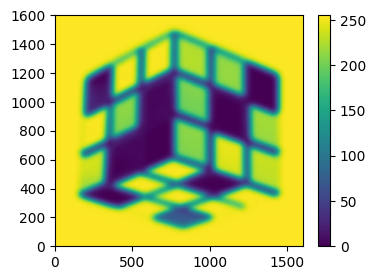

In [21]:
plt.figure(figsize = (4,3))

Z1 = plt.pcolor(smooth_im3, shading='auto', cmap ="viridis")

plt.colorbar(Z1)

plt.show()
#plt.savefig("sigma8.png")

We are yet to manage an actual image. We've just used one layer images. Since images usually have 3 layers (RGB), we need to carry out the smoothing on each layer and then construct the full smoothed image.